# Multi Result Full Laplacian Hessian Spectrum Diagnosis

本 notebook 在一个固定文件中对多个 sandbox 结果做完整单结果诊断。顶部配置发现带 Hessian sidecar 的结果，并通过 `RESULT_INDEX` 或 `RESULT_PATH` 选择其中一条；后续谱结构、large-eigenvalue subspace、near-null subspace、coordinate attribution 和 weak-visibility chain 分析沿用 `laplacian_hessian_spectrum_diagnosis.ipynb` 的完整逻辑。


## 1 Data And Hessian Reconstruction

本节发现 sandbox retargeting result，选择一个 result 和对应 Hessian sidecar，然后读取每条 record 的 saved Laplacian Hessian、active $q$、$J_V$、$J_{\mathrm{lap}}$、row weights 和 interaction vertices。

Sidecar 中的 Laplacian Hessian 应满足：

$$
H_r = 2J_{\mathrm{lap},r}^TW_rJ_{\mathrm{lap},r}.
$$

Reconstruction error 在所有 records 上统计，用于确认后续谱分析使用的矩阵和 saved Jacobian-side diagnostics 一致。


In [51]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 140)


def find_workspace_root(start: Path | None = None) -> Path:
    path = (start or Path.cwd()).resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "Retarget").is_dir() and (candidate / "holosoma_retargeting").is_dir():
            return candidate
    raise RuntimeError("Cannot find Retarget-whole workspace root")


REPO_ROOT = find_workspace_root()
HOLOSOMA_ROOT = REPO_ROOT / "holosoma_retargeting" / "holosoma_retargeting"
RESULT_VARIANTS = [
    "sandbox_experimental",
    "sandbox_extra_keypoints_experimental",
    "sandbox_extra_keypoints_offsets_experimental",
    "sandbox_removed_experimental",
]
RESULT_ROOTS = [HOLOSOMA_ROOT / "demo_results_total" / variant / "g1" for variant in RESULT_VARIANTS]

RESULT_PATH: str | Path | None = None
RESULT_INDEX = 17
INCLUDE_SUBSTRINGS: list[str] = []
EXCLUDE_SUBSTRINGS = ["_hessian_components", "laplacian_hessian_reports"]
MAX_RESULTS: int | None = None


def resolve_path(path: str | Path) -> Path:
    path = Path(path).expanduser()
    if path.is_absolute():
        return path.resolve()
    holosoma_candidate = (HOLOSOMA_ROOT / path).resolve()
    repo_candidate = (REPO_ROOT / path).resolve()
    if holosoma_candidate.exists() or str(path).startswith("demo_results_total"):
        return holosoma_candidate
    return repo_candidate


def path_label(path: Path) -> str:
    try:
        return str(path.resolve().relative_to(HOLOSOMA_ROOT))
    except ValueError:
        try:
            return str(path.resolve().relative_to(REPO_ROOT))
        except ValueError:
            return str(path)


def path_selected(path: Path) -> bool:
    text = str(path)
    if any(token in text for token in EXCLUDE_SUBSTRINGS):
        return False
    if INCLUDE_SUBSTRINGS and not any(token in text for token in INCLUDE_SUBSTRINGS):
        return False
    return True


def sidecar_for_result(result_path: Path) -> Path | None:
    try:
        result_data = np.load(result_path, allow_pickle=True)
    except Exception:
        return None
    if "hessian_components_file" not in result_data.files:
        return None
    sidecar_path = result_path.with_name(str(result_data["hessian_components_file"].item()))
    if not sidecar_path.exists():
        return None
    return sidecar_path


def discover_result_paths() -> list[Path]:
    valid: list[Path] = []
    for root in RESULT_ROOTS:
        if not root.exists():
            continue
        for result_path in root.rglob("*.npz"):
            if not path_selected(result_path):
                continue
            if sidecar_for_result(result_path) is None:
                continue
            valid.append(result_path.resolve())
    valid = sorted(dict.fromkeys(valid), key=lambda p: path_label(p))
    if MAX_RESULTS is not None:
        valid = valid[: int(MAX_RESULTS)]
    return valid


result_paths = discover_result_paths()
if RESULT_PATH is None:
    if not result_paths:
        raise FileNotFoundError(f"No result .npz with Hessian sidecar found under {RESULT_ROOTS}")
    if not (0 <= int(RESULT_INDEX) < len(result_paths)):
        raise IndexError(f"RESULT_INDEX={RESULT_INDEX} outside discovered result range 0..{len(result_paths) - 1}")
    NPZ_PATH = result_paths[int(RESULT_INDEX)]
else:
    NPZ_PATH = resolve_path(RESULT_PATH)

if not NPZ_PATH.exists():
    raise FileNotFoundError(NPZ_PATH)

selection_rows = []
for idx, result_path in enumerate(result_paths):
    sidecar_path = sidecar_for_result(result_path)
    result_data_for_table = np.load(result_path, allow_pickle=True)
    selection_rows.append(
        {
            "index": idx,
            "selected": result_path == NPZ_PATH.resolve(),
            "result": path_label(result_path),
            "sidecar": path_label(sidecar_path) if sidecar_path is not None else None,
            "qpos_shape": tuple(result_data_for_table["qpos"].shape) if "qpos" in result_data_for_table.files else None,
        }
    )
if selection_rows:
    display(pd.DataFrame(selection_rows))

result_data = np.load(NPZ_PATH, allow_pickle=True)
hessian_components_name = str(result_data["hessian_components_file"].item())
hessian_components_path = NPZ_PATH.with_name(hessian_components_name)
if not hessian_components_path.exists():
    raise FileNotFoundError(hessian_components_path)

hessian_data = np.load(hessian_components_path, allow_pickle=True)
component_names = [str(x) for x in hessian_data["hessian_component_names"]]
lap_index = component_names.index("lap")
lap_mats_raw = np.asarray(hessian_data["hessian_component_matrices"][:, lap_index], dtype=float)
lap_mats = 0.5 * (lap_mats_raw + np.swapaxes(lap_mats_raw, -1, -2))
hessian_frame = hessian_data["hessian_frame"].astype(int)
hessian_inner_iter = hessian_data["hessian_inner_iter"].astype(int)

REQUIRED_LAP_DIAGNOSTIC_FIELDS = [
    "hessian_q_active",
    "hessian_q_eval",
    "hessian_lap_J_V",
    "hessian_lap_J_lap",
    "hessian_lap_weights",
    "hessian_lap_vertices",
    "hessian_lap_num_robot_vertices",
    "hessian_lap_robot_link_keys",
]
missing_lap_diagnostic_fields = [
    key for key in REQUIRED_LAP_DIAGNOSTIC_FIELDS if key not in hessian_data.files
]
if missing_lap_diagnostic_fields:
    raise KeyError(f"Missing exact Laplacian diagnostic fields: {missing_lap_diagnostic_fields}")

q_active_all = np.asarray(hessian_data["hessian_q_active"], dtype=float)
q_eval_all = np.asarray(hessian_data["hessian_q_eval"], dtype=float)
lap_J_V_all = np.asarray(hessian_data["hessian_lap_J_V"], dtype=float)
lap_J_lap_all = np.asarray(hessian_data["hessian_lap_J_lap"], dtype=float)
lap_weights_all = np.asarray(hessian_data["hessian_lap_weights"], dtype=float)
lap_vertices_all = np.asarray(hessian_data["hessian_lap_vertices"], dtype=float)
lap_num_robot_vertices_all = np.asarray(hessian_data["hessian_lap_num_robot_vertices"], dtype=int)
lap_robot_link_keys = np.asarray(hessian_data["hessian_lap_robot_link_keys"], dtype=str)

num_records = lap_mats.shape[0]
nq_a = lap_mats.shape[-1]
lap_evals_all = np.linalg.eigvalsh(lap_mats)
lap_evals_desc_all = lap_evals_all[:, ::-1]
lap_lambda_max = lap_evals_all[:, -1]


def symmetrize(H):
    H = np.asarray(H, dtype=float)
    return 0.5 * (H + H.T)


def hessian_from_jacobian(J, weights):
    J = np.asarray(J, dtype=float)
    weights = np.asarray(weights, dtype=float).reshape(-1)
    return symmetrize(2.0 * (J.T @ (weights[:, None] * J)))


reconstruction_abs_diff = np.empty(num_records, dtype=float)
reconstruction_rel_diff = np.empty(num_records, dtype=float)
for record_idx in range(num_records):
    H_reconstructed = hessian_from_jacobian(
        lap_J_lap_all[record_idx],
        lap_weights_all[record_idx],
    )
    diff = float(np.max(np.abs(H_reconstructed - lap_mats[record_idx])))
    denom = max(float(np.max(np.abs(lap_mats[record_idx]))), 1e-300)
    reconstruction_abs_diff[record_idx] = diff
    reconstruction_rel_diff[record_idx] = diff / denom

print("selected result index:", RESULT_INDEX if RESULT_PATH is None else "explicit RESULT_PATH")
print("result file:", NPZ_PATH)
print("Hessian file:", hessian_components_path)
print("component names:", component_names)
print("records:", num_records)
print("nq active:", nq_a)
print("q active shape:", q_active_all.shape)
print("J_V shape:", lap_J_V_all.shape)
print("J_lap shape:", lap_J_lap_all.shape)
print("weights shape:", lap_weights_all.shape)
print("robot vertex counts:", np.unique(lap_num_robot_vertices_all))
print("robot link keys:", len(lap_robot_link_keys))
print("max abs reconstruction error:", float(np.max(reconstruction_abs_diff)))
print("p95 abs reconstruction error:", float(np.percentile(reconstruction_abs_diff, 95)))
print("max relative reconstruction error:", float(np.max(reconstruction_rel_diff)))


,index,selected,result,sidecar,qpos_shape
0,0,False,demo_results_total/sandbox_experimental/g1/climbing/mocap_climb/mocap_climb_seq_0_original.npz,demo_results_total/sandbox_experimental/g1/climbing/mocap_climb/mocap_climb_seq_0_original_hessian_components.npz,"(701, 36)"
1,1,False,demo_results_total/sandbox_experimental/g1/climbing/mocap_climb/mocap_climb_seq_1_original.npz,demo_results_total/sandbox_experimental/g1/climbing/mocap_climb/mocap_climb_seq_1_original_hessian_components.npz,"(606, 36)"
2,2,False,demo_results_total/sandbox_experimental/g1/climbing/mocap_climb/mocap_climb_seq_2_original.npz,demo_results_total/sandbox_experimental/g1/climbing/mocap_climb/mocap_climb_seq_2_original_hessian_components.npz,"(753, 36)"
3,3,False,demo_results_total/sandbox_experimental/g1/climbing/mocap_climb/mocap_climb_seq_3_original.npz,demo_results_total/sandbox_experimental/g1/climbing/mocap_climb/mocap_climb_seq_3_original_hessian_components.npz,"(601, 36)"
4,4,False,demo_results_total/sandbox_experimental/g1/climbing/mocap_climb/mocap_climb_seq_4_original.npz,demo_results_total/sandbox_experimental/g1/climbing/mocap_climb/mocap_climb_seq_4_original_hessian_components.npz,"(576, 36)"
5,5,False,demo_results_total/sandbox_experimental/g1/object_interaction/omomo/sub10_largebox_049_original.npz,demo_results_total/sandbox_experimental/g1/object_interaction/omomo/sub10_largebox_049_original_hessian_components.npz,"(222, 43)"
6,6,False,demo_results_total/sandbox_experimental/g1/object_interaction/omomo/sub3_largebox_003_original.npz,demo_results_total/sandbox_experimental/g1/object_interaction/omomo/sub3_largebox_003_original_hessian_components.npz,"(196, 43)"
7,7,False,demo_results_total/sandbox_experimental/g1/robot_only/retarget_lafan/aiming1_subject1.npz,demo_results_total/sandbox_experimental/g1/robot_only/retarget_lafan/aiming1_subject1_hessian_components.npz,"(7184, 36)"
8,8,False,demo_results_total/sandbox_experimental/g1/robot_only/retarget_lafan_npz/dance1_subject2.npz,demo_results_total/sandbox_experimental/g1/robot_only/retarget_lafan_npz/dance1_subject2_hessian_components.npz,"(3945, 36)"
9,9,False,demo_results_total/sandbox_experimental/g1/robot_only/retarget_lafan_npz/dance2_subject5.npz,demo_results_total/sandbox_experimental/g1/robot_only/retarget_lafan_npz/dance2_subject5_hessian_components.npz,"(6771, 36)"


selected result index: 17
result file: /home/cipher/Codes/Academic-Projects/Retarget-whole/holosoma_retargeting/holosoma_retargeting/demo_results_total/sandbox_removed_experimental/g1/robot_only/retarget_lafan/aiming1_subject1.npz
Hessian file: /home/cipher/Codes/Academic-Projects/Retarget-whole/holosoma_retargeting/holosoma_retargeting/demo_results_total/sandbox_removed_experimental/g1/robot_only/retarget_lafan/aiming1_subject1_hessian_components.npz
component names: ['lap', 'lap_j_only', 'lap_robot_rows', 'lap_object_rows', 'nominal', 'q_diag', 'smooth', 'total']
records: 3108
nq active: 30
q active shape: (3108, 30)
J_V shape: (3108, 720, 30)
J_lap shape: (3108, 720, 30)
weights shape: (3108, 720)
robot vertex counts: [15]
robot link keys: 15
max abs reconstruction error: 0.0
p95 abs reconstruction error: 0.0
max relative reconstruction error: 0.0


## 2 All-Record Spectrum Overview

本节在所有 records 上统计 Laplacian Hessian 的谱两端。特征值按降序记为：

$$
\lambda_1^{(r)}\ge \lambda_2^{(r)}\ge\cdots\ge \lambda_n^{(r)}.
$$

本 notebook 使用的阈值参数为：

$$
\tau_{s,\mathrm{abs}}=1.0,\qquad
\tau_{s,\mathrm{rel}}=10^{-1},\qquad
\tau_{0,\mathrm{abs}}=10^{-5},\qquad
\tau_{0,\mathrm{rel}}=10^{-7}.
$$

Stiff threshold 和 near-zero threshold 分别为：

$$
\tau_s^{(r)}=\max(\tau_{s,\mathrm{abs}},\tau_{s,\mathrm{rel}}\lambda_1^{(r)}),
\qquad
\tau_0^{(r)}=\max(\tau_{0,\mathrm{abs}},\tau_{0,\mathrm{rel}}\lambda_1^{(r)}).
$$

对应 count 为：

$$
k_s^{(r)}=\#\{i:\lambda_i^{(r)}\ge\tau_s^{(r)}\},
\qquad
k_0^{(r)}=\#\{i:\lambda_i^{(r)}\le\tau_0^{(r)}\}.
$$


In [52]:
RAW_NEAR_ZERO_ABS_TOL = 1e-5
RAW_NEAR_ZERO_REL_TOL = 1e-7
RAW_STIFF_ABS_TOL = 1.0
RAW_STIFF_REL_TOL = 1e-1
SPECTRAL_GAP_EPS = 1e-300

def safe_divide(numerator, denominator, tol=1e-300):
    denominator = float(denominator)
    return float("nan") if abs(denominator) <= tol else float(numerator) / denominator

def eigenvalue_near_zero_tol(evals, rel_tol=RAW_NEAR_ZERO_REL_TOL, abs_tol=RAW_NEAR_ZERO_ABS_TOL):
    evals = np.asarray(evals, dtype=float).reshape(-1)
    if evals.size == 0:
        return abs_tol
    lambda_max = max(float(np.nanmax(evals)), 0.0)
    return max(abs_tol, rel_tol * lambda_max)

def eigenvalue_stiff_tol(evals, rel_tol=RAW_STIFF_REL_TOL, abs_tol=RAW_STIFF_ABS_TOL):
    evals = np.asarray(evals, dtype=float).reshape(-1)
    if evals.size == 0:
        return abs_tol
    lambda_max = max(float(np.nanmax(evals)), 0.0)
    return max(abs_tol, rel_tol * lambda_max)

def hessian_spectrum_metrics(evals):
    evals = np.asarray(evals, dtype=float).reshape(-1)
    if evals.size == 0:
        return {
            "lambda_max": float("nan"),
            "lambda_min_positive": float("nan"),
            "rank_eff": 0,
            "near_zero_count": 0,
            "stiff_count": 0,
            "near_zero_tol": RAW_NEAR_ZERO_ABS_TOL,
            "stiff_tol": RAW_STIFF_ABS_TOL,
            "observed_condition": float("nan"),
            "near_tail_max_abs": float("nan"),
            "spectral_gap_after_tail": float("nan"),
        }
    near_tol = eigenvalue_near_zero_tol(evals)
    stiff_tol = eigenvalue_stiff_tol(evals)
    observable = evals > near_tol
    positive = evals[observable]
    near_tail = evals[~observable]
    lambda_max = float(evals[-1])
    lambda_min_positive = float(positive[0]) if positive.size else float("nan")
    near_tail_max_abs = float(np.max(np.abs(near_tail))) if near_tail.size else float("nan")
    observed_condition = safe_divide(lambda_max, lambda_min_positive) if positive.size else float("nan")
    spectral_gap = (
        safe_divide(lambda_min_positive, near_tail_max_abs, tol=SPECTRAL_GAP_EPS)
        if positive.size and near_tail.size
        else float("nan")
    )
    return {
        "lambda_max": lambda_max,
        "lambda_min_positive": lambda_min_positive,
        "rank_eff": int(positive.size),
        "near_zero_count": int(evals.size - positive.size),
        "stiff_count": int(np.sum(evals >= stiff_tol)),
        "near_zero_tol": float(near_tol),
        "stiff_tol": float(stiff_tol),
        "observed_condition": float(observed_condition),
        "near_tail_max_abs": near_tail_max_abs,
        "spectral_gap_after_tail": float(spectral_gap),
    }

def metric_series(evals_all, key):
    return np.array([hessian_spectrum_metrics(evals)[key] for evals in evals_all], dtype=float)

def percentile_summary(values, percentiles=(0, 5, 50, 95, 100)):
    values = np.asarray(values, dtype=float).reshape(-1)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return {f"p{pct:g}": float("nan") for pct in percentiles}
    return {f"p{pct:g}": float(np.percentile(finite, pct)) for pct in percentiles}

def percentile_summary_table(rows, percentiles=(0, 5, 50, 95, 100)):
    return pd.DataFrame(
        [
            {"metric": metric, **percentile_summary(values, percentiles=percentiles)}
            for metric, values in rows
        ]
    ).set_index("metric").rename_axis(None)

def add_rank_x_grid(ax, eig_rank):
    for rank in eig_rank:
        if rank in {1, 2, 3, 5, 10, 20, 30, 36}:
            ax.axvline(rank, color="gray", alpha=0.12, linewidth=0.7)

def fmt_metric(value, width=14):
    if isinstance(value, (np.integer, int)):
        return f"{int(value):{width}d}"
    value = float(value)
    if not np.isfinite(value):
        return f"{'nan':>{width}s}"
    return f"{value:{width}.6g}"

spectrum_metric_keys = [
    "lambda_max",
    "lambda_min_positive",
    "rank_eff",
    "near_zero_count",
    "stiff_count",
    "near_zero_tol",
    "stiff_tol",
    "observed_condition",
    "near_tail_max_abs",
    "spectral_gap_after_tail",
]
lap_metric_series = {key: metric_series(lap_evals_all, key) for key in spectrum_metric_keys}
overview_metric_keys = ["lambda_max", "rank_eff", "near_zero_count", "stiff_count"]

overview_table = percentile_summary_table(
    [(key, lap_metric_series[key]) for key in overview_metric_keys]
)
display(Markdown("**per-record H_lap spectrum percentiles**"))
display(overview_table.style.format("{:.8g}"))

near_zero_values, near_zero_freq = np.unique(lap_metric_series["near_zero_count"].astype(int), return_counts=True)
stiff_values, stiff_freq = np.unique(lap_metric_series["stiff_count"].astype(int), return_counts=True)
modal_near_zero_count = int(near_zero_values[np.argmax(near_zero_freq)]) if near_zero_values.size else 0
modal_stiff_count = int(stiff_values[np.argmax(stiff_freq)]) if stiff_values.size else 1

near_zero_distribution = pd.DataFrame(
    {"near_zero_count": near_zero_values.astype(int), "record_count": near_zero_freq.astype(int)}
)
stiff_distribution = pd.DataFrame(
    {"stiff_count": stiff_values.astype(int), "record_count": stiff_freq.astype(int)}
)

display(Markdown("**near-zero count distribution**"))
display(near_zero_distribution)
display(Markdown("**stiff count distribution**"))
display(stiff_distribution)


**per-record H_lap spectrum percentiles**

,p0,p5,p50,p95,p100
lambda_max,211.8213,223.80136,288.07666,397.131,483.84283
rank_eff,27,29,29,29,29
near_zero_count,1,1,1,1,3
stiff_count,6,6,6,6,7


**near-zero count distribution**

,near_zero_count,record_count
0,1,3065
1,2,35
2,3,8


**stiff count distribution**

,stiff_count,record_count
0,6,3028
1,7,80


### 2.1 Single-Record Spectrum Structure Example

本节单独选取一个 peak $\lambda_1$ record，画出该 record 的降序谱结构，用来说明 stiff directions、observable middle directions 和 near-zero tail 的划分。


**Peak-record 谱结构示例**

示例 record 取所有 saved records 中 $\lambda_1$ 最大的一条：record `373`，frame `950`，inner_iter `0`。

- 橙色区域：$\lambda_i\ge	au_s$，即 large-eigenvalue / stiff directions，数量 $k_s=6$。
- 红色区域：$\lambda_i\le	au_0$，即 near-zero tail，数量 $k_0=1$。
- 中间区域：可观测但未被归为 stiff 的方向。

metric,value
record,373
frame,950
inner_iter,0
lambda_max,483.84283
stiff_tol,48.384283
stiff_count,6
near_zero_tol,4.8384283e-05
near_zero_count,1
rank_eff,29


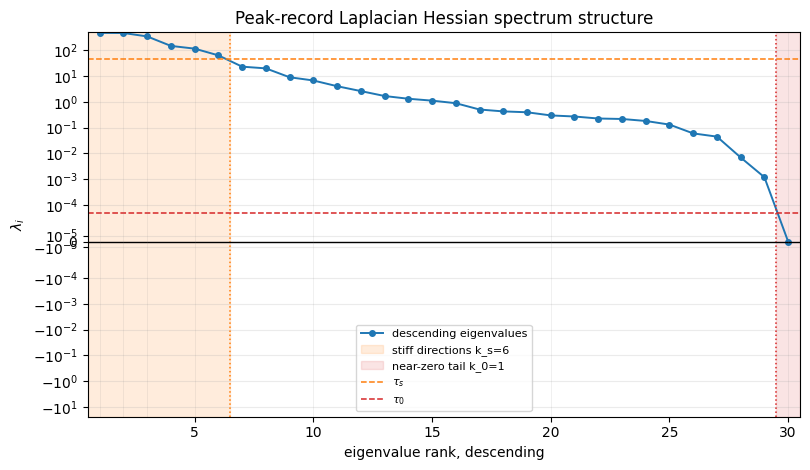

In [53]:
example_record_idx = int(np.nanargmax(lap_metric_series["lambda_max"]))
example_evals_asc = np.asarray(lap_evals_all[example_record_idx], dtype=float)
example_evals_desc = example_evals_asc[::-1]
example_metrics = hessian_spectrum_metrics(example_evals_asc)
example_rank = np.arange(1, example_evals_desc.size + 1)

example_k_s = int(example_metrics["stiff_count"])
example_k_0 = int(example_metrics["near_zero_count"])
example_rank_eff = int(example_metrics["rank_eff"])
example_stiff_tol = float(example_metrics["stiff_tol"])
example_near_tol = float(example_metrics["near_zero_tol"])
example_frame = int(hessian_frame[example_record_idx])
example_inner_iter = int(hessian_inner_iter[example_record_idx])

example_summary_df = pd.DataFrame(
    [
        {"metric": "record", "value": example_record_idx},
        {"metric": "frame", "value": example_frame},
        {"metric": "inner_iter", "value": example_inner_iter},
        {"metric": "lambda_max", "value": example_metrics["lambda_max"]},
        {"metric": "stiff_tol", "value": example_stiff_tol},
        {"metric": "stiff_count", "value": example_k_s},
        {"metric": "near_zero_tol", "value": example_near_tol},
        {"metric": "near_zero_count", "value": example_k_0},
        {"metric": "rank_eff", "value": example_rank_eff},
    ]
)

display(Markdown(
    f"""
**Peak-record 谱结构示例**

示例 record 取所有 saved records 中 $\lambda_1$ 最大的一条：record `{example_record_idx}`，frame `{example_frame}`，inner_iter `{example_inner_iter}`。

- 橙色区域：$\lambda_i\ge\tau_s$，即 large-eigenvalue / stiff directions，数量 $k_s={example_k_s}$。
- 红色区域：$\lambda_i\le\tau_0$，即 near-zero tail，数量 $k_0={example_k_0}$。
- 中间区域：可观测但未被归为 stiff 的方向。
""".strip()
))
display(example_summary_df.style.hide(axis="index").format({"value": "{:.8g}"}))

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(
    example_rank,
    example_evals_desc,
    marker="o",
    markersize=4,
    linewidth=1.4,
    color="tab:blue",
    label="descending eigenvalues",
)
if example_k_s > 0:
    ax.axvspan(0.5, example_k_s + 0.5, color="tab:orange", alpha=0.14, label=f"stiff directions k_s={example_k_s}")
    if example_k_s < example_evals_desc.size:
        ax.axvline(example_k_s + 0.5, color="tab:orange", linestyle=":", linewidth=1.1)
if example_k_0 > 0:
    near_start_rank = example_evals_desc.size - example_k_0 + 1
    ax.axvspan(near_start_rank - 0.5, example_evals_desc.size + 0.5, color="tab:red", alpha=0.12, label=f"near-zero tail k_0={example_k_0}")
    if near_start_rank > 1:
        ax.axvline(near_start_rank - 0.5, color="tab:red", linestyle=":", linewidth=1.1)
ax.axhline(0.0, color="black", linewidth=1.0)
ax.axhline(example_stiff_tol, color="tab:orange", linestyle="--", linewidth=1.1, label=r"$\tau_s$")
ax.axhline(example_near_tol, color="tab:red", linestyle="--", linewidth=1.1, label=r"$\tau_0$")
ax.set_yscale("symlog", linthresh=max(example_near_tol, 1e-12))
ax.set_title("Peak-record Laplacian Hessian spectrum structure")
ax.set_xlabel("eigenvalue rank, descending")
ax.set_ylabel(r"$\lambda_i$")
ax.set_xlim(0.5, example_evals_desc.size + 0.5)
ax.legend(fontsize=8, loc="best")
ax.grid(True, axis="y", alpha=0.25)
add_rank_x_grid(ax, example_rank)
plt.tight_layout()
plt.show()


### 2.2 Representative Multi-Record Spectra

该图按每条 record 的最大特征值 $\lambda_{\max}^{(r)}$ 的分位数选取代表 records，展示 raw spectrum 曲线和全体 records 的 signed-log spectrum heatmap。


representative spectrum records
   pct   record   frame  iter     lambda_max    stiff  near_zero
   0.0     2414    5670     3        211.821        6          1
  10.0      296     730     1        228.343        6          1
  25.0     1626    3710     0        243.966        6          1
  50.0     1388    3040     5        288.076        6          1
  75.0     2472    5800     0        334.037        6          1
  90.0     3021    6960     0        371.553        6          1
  95.0      203     450     1        397.181        6          1
  99.0     1013    2200     1         439.61        6          1
 100.0      373     950     0        483.843        6          1


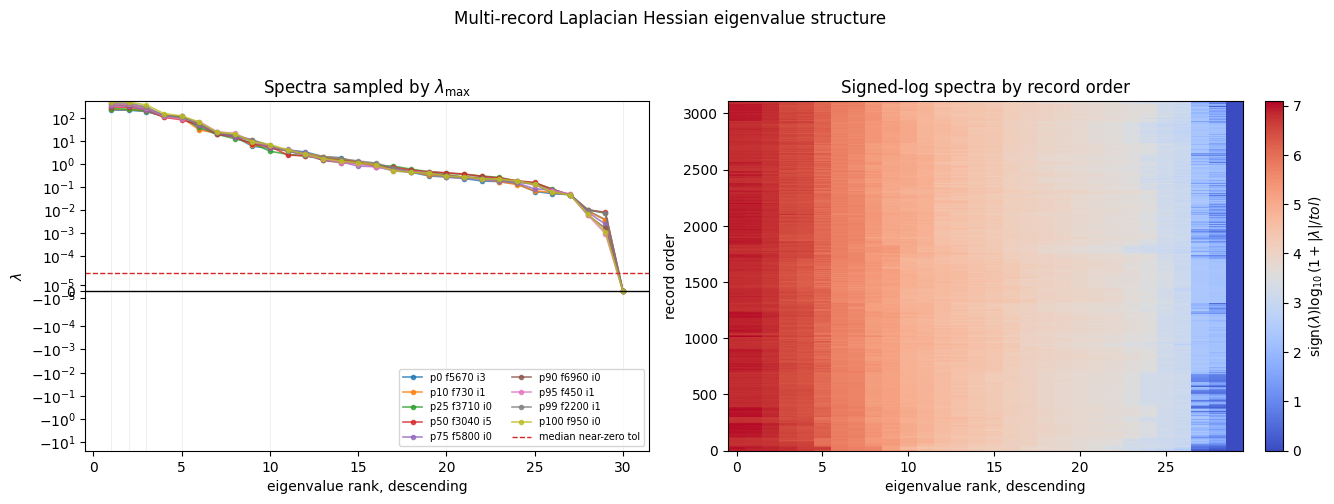

In [54]:
if "fmt_metric" not in globals():
    def fmt_metric(value, width=14):
        if isinstance(value, (np.integer, int)):
            return f"{int(value):{width}d}"
        value = float(value)
        if not np.isfinite(value):
            return f"{'nan':>{width}s}"
        return f"{value:{width}.6g}"

def nearest_quantile_records(values, percentiles):
    values = np.asarray(values, dtype=float).reshape(-1)
    finite = np.flatnonzero(np.isfinite(values))
    records = []
    if finite.size == 0:
        return records
    finite_values = values[finite]
    for pct in percentiles:
        target = float(np.nanpercentile(finite_values, pct))
        idx = int(finite[np.nanargmin(np.abs(finite_values - target))])
        records.append((float(pct), idx, target, float(values[idx])))
    return records

lambda_quantile_records = nearest_quantile_records(lap_lambda_max, [0, 10, 25, 50, 75, 90, 95, 99, 100])

print("representative spectrum records")
print(
    f"{'pct':>6s} {'record':>8s} {'frame':>7s} {'iter':>5s} "
    f"{'lambda_max':>14s} {'stiff':>8s} {'near_zero':>10s}"
)
for pct, idx, target, actual in lambda_quantile_records:
    metrics = hessian_spectrum_metrics(lap_evals_all[idx])
    print(
        f"{pct:6.1f} {idx:8d} {int(hessian_frame[idx]):7d} {int(hessian_inner_iter[idx]):5d} "
        f"{fmt_metric(metrics['lambda_max'])} "
        f"{fmt_metric(metrics['stiff_count'], width=8)} {fmt_metric(metrics['near_zero_count'], width=10)}"
    )

eig_rank = np.arange(1, lap_evals_desc_all.shape[1] + 1)
plot_linthresh = max(float(np.nanpercentile(lap_metric_series["near_zero_tol"], 95)), 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

ax = axes[0]
for pct, idx, target, actual in lambda_quantile_records:
    ax.plot(
        eig_rank,
        lap_evals_desc_all[idx],
        marker="o",
        markersize=3,
        linewidth=1.2,
        alpha=0.78,
        label=f"p{pct:g} f{int(hessian_frame[idx])} i{int(hessian_inner_iter[idx])}",
    )
ax.axhline(0.0, color="black", linewidth=1)
ax.axhline(float(np.nanmedian(lap_metric_series["near_zero_tol"])), color="tab:red", linestyle="--", linewidth=1, label="median near-zero tol")
ax.set_yscale("symlog", linthresh=plot_linthresh)
ax.set_title(r"Spectra sampled by $\lambda_{\max}$")
ax.set_xlabel("eigenvalue rank, descending")
ax.set_ylabel(r"$\lambda$")
ax.legend(fontsize=7, ncol=2)
add_rank_x_grid(ax, eig_rank)

ax = axes[1]
signed_log_evals = np.sign(lap_evals_desc_all) * np.log10(1.0 + np.abs(lap_evals_desc_all) / plot_linthresh)
image = ax.imshow(
    signed_log_evals,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="coolwarm",
)
ax.set_title("Signed-log spectra by record order")
ax.set_xlabel("eigenvalue rank, descending")
ax.set_ylabel("record order")
cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"sign$(\lambda)\log_{10}(1 + |\lambda| / tol)$")

fig.suptitle("Multi-record Laplacian Hessian eigenvalue structure", y=1.04)
plt.tight_layout()
plt.show()


### 2.3 Spectrum Percentile Bands

Percentile bands summarize the full spectrum over all records. The normalized spectrum uses

$$
\mu_i^{(r)}=\frac{\lambda_i^{(r)}}{\lambda_1^{(r)}}
$$

to remove record-wise scale and retain spectrum shape.


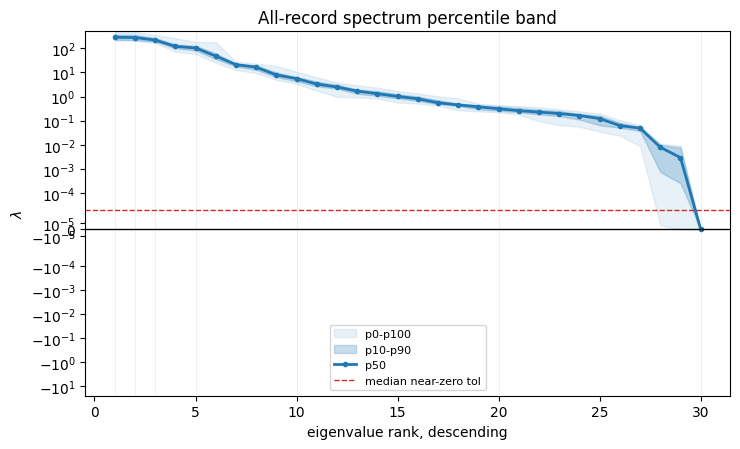

normalized spectrum percentiles by eigenvalue rank
  rank             p5            p50            p95         p95-p5
     1 1.00000000e+00 1.00000000e+00 1.00000000e+00 0.00000000e+00
     2 9.51153140e-01 9.80923204e-01 9.93659677e-01 4.25065370e-02
     3 6.79933184e-01 7.66756873e-01 8.75282197e-01 1.95349013e-01
     5 2.49228816e-01 3.51191188e-01 5.37810869e-01 2.88582053e-01
    10 1.26210277e-02 1.92606040e-02 2.79545322e-02 1.53335045e-02
    20 7.52697680e-04 1.08566993e-03 1.53393040e-03 7.81232723e-04
    25 2.32740319e-04 3.80504732e-04 5.96450654e-04 3.63710335e-04
    30 -4.18423602e-16 -2.88373314e-18 3.79736083e-16 7.98159685e-16


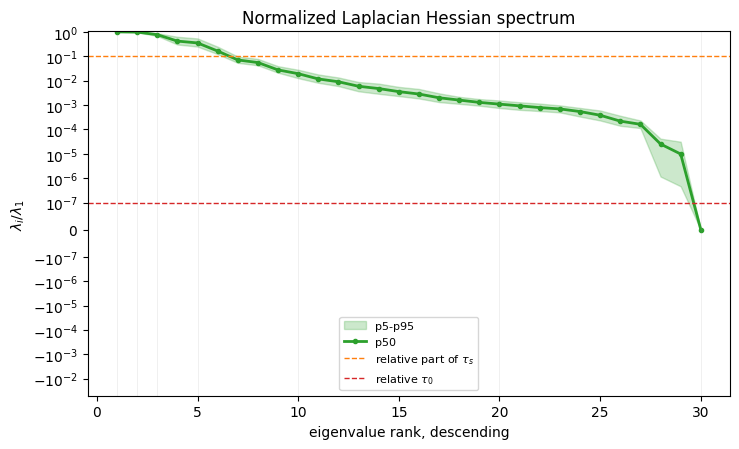

In [55]:
eig_rank = np.arange(1, lap_evals_desc_all.shape[1] + 1)
p0, p10, p50, p90, p100 = np.nanpercentile(
    lap_evals_desc_all,
    [0, 10, 50, 90, 100],
    axis=0,
)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.fill_between(eig_rank, p0, p100, color="tab:blue", alpha=0.10, label="p0-p100")
ax.fill_between(eig_rank, p10, p90, color="tab:blue", alpha=0.24, label="p10-p90")
ax.plot(eig_rank, p50, color="tab:blue", marker="o", markersize=3, linewidth=2.0, label="p50")
ax.axhline(0.0, color="black", linewidth=1)
ax.axhline(float(np.nanmedian(lap_metric_series["near_zero_tol"])), color="tab:red", linestyle="--", linewidth=1, label="median near-zero tol")
ax.set_yscale("symlog", linthresh=plot_linthresh)
ax.set_title("All-record spectrum percentile band")
ax.set_xlabel("eigenvalue rank, descending")
ax.set_ylabel(r"$\lambda$")
ax.legend(fontsize=8)
add_rank_x_grid(ax, eig_rank)
plt.tight_layout()
plt.show()

lambda_scale = np.where(lap_lambda_max > 0, lap_lambda_max, np.nan)
normalized_lap_evals_desc_all = lap_evals_desc_all / lambda_scale[:, None]

selected_ranks = [
    rank for rank in [1, 2, 3, 5, 10, 20, 25, 30, 31, 32, 36]
    if rank <= normalized_lap_evals_desc_all.shape[1]
]
print("normalized spectrum percentiles by eigenvalue rank")
print(f"{'rank':>6s} {'p5':>14s} {'p50':>14s} {'p95':>14s} {'p95-p5':>14s}")
for rank in selected_ranks:
    values = normalized_lap_evals_desc_all[:, rank - 1]
    p5_rank, p50_rank, p95_rank = np.nanpercentile(values, [5, 50, 95])
    print(f"{rank:6d} {p5_rank:14.8e} {p50_rank:14.8e} {p95_rank:14.8e} {p95_rank - p5_rank:14.8e}")

norm_p5, norm_p50, norm_p95 = np.nanpercentile(normalized_lap_evals_desc_all, [5, 50, 95], axis=0)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.fill_between(eig_rank, norm_p5, norm_p95, color="tab:green", alpha=0.24, label="p5-p95")
ax.plot(eig_rank, norm_p50, color="tab:green", marker="o", markersize=3, linewidth=2.0, label="p50")
ax.axhline(RAW_STIFF_REL_TOL, color="tab:orange", linestyle="--", linewidth=1, label=r"relative part of $\tau_s$")
ax.axhline(RAW_NEAR_ZERO_REL_TOL, color="tab:red", linestyle="--", linewidth=1, label=r"relative $\tau_0$")
ax.set_yscale("symlog", linthresh=max(RAW_NEAR_ZERO_REL_TOL, 1e-12))
ax.set_title("Normalized Laplacian Hessian spectrum")
ax.set_xlabel("eigenvalue rank, descending")
ax.set_ylabel(r"$\lambda_i / \lambda_1$")
ax.legend(fontsize=8)
add_rank_x_grid(ax, eig_rank)
plt.tight_layout()
plt.show()


## 3 Shared Raw-q And Subspace Tools

本节定义 raw active $q$ 坐标标签、变量 block、weighted residual Jacobian、subspace distance、participation 和 attribution helper functions。Large-eigenvalue 与 near-null 分析共用这些工具。


In [56]:
def show_note(text):
    display(Markdown(text))

def show_df(df):
    display(df.style.hide(axis="index"))

G1_ACTUATED_Q_NAMES = [
    "left_hip_pitch_joint",
    "left_hip_roll_joint",
    "left_hip_yaw_joint",
    "left_knee_joint",
    "left_ankle_pitch_joint",
    "left_ankle_roll_joint",
    "right_hip_pitch_joint",
    "right_hip_roll_joint",
    "right_hip_yaw_joint",
    "right_knee_joint",
    "right_ankle_pitch_joint",
    "right_ankle_roll_joint",
    "waist_yaw_joint",
    "waist_roll_joint",
    "waist_pitch_joint",
    "left_shoulder_pitch_joint",
    "left_shoulder_roll_joint",
    "left_shoulder_yaw_joint",
    "left_elbow_joint",
    "left_wrist_roll_joint",
    "left_wrist_pitch_joint",
    "left_wrist_yaw_joint",
    "right_shoulder_pitch_joint",
    "right_shoulder_roll_joint",
    "right_shoulder_yaw_joint",
    "right_elbow_joint",
    "right_wrist_roll_joint",
    "right_wrist_pitch_joint",
    "right_wrist_yaw_joint",
]

fallback_raw_q_names = ["base_x", "base_y", "base_z", "base_qw", "base_qx", "base_qy", "base_qz"] + G1_ACTUATED_Q_NAMES
if "hessian_q_active_names" in hessian_data.files:
    raw_q_names = [str(name) for name in hessian_data["hessian_q_active_names"]]
else:
    raw_q_names = list(fallback_raw_q_names)
if len(raw_q_names) < nq_a:
    raw_q_names += [f"q_{i}" for i in range(len(raw_q_names), nq_a)]
raw_q_names = raw_q_names[:nq_a]

if "hessian_q_active_indices" in hessian_data.files:
    raw_q_full_indices = np.asarray(hessian_data["hessian_q_active_indices"], dtype=int).reshape(-1)
else:
    raw_q_full_indices = np.arange(nq_a, dtype=int)
if raw_q_full_indices.size < nq_a:
    raw_q_full_indices = np.concatenate([raw_q_full_indices, np.arange(raw_q_full_indices.size, nq_a, dtype=int)])
raw_q_full_indices = raw_q_full_indices[:nq_a]

RAW_Q_GROUPS = {
    "base_translation": slice(0, min(3, nq_a)),
    "base_quaternion": slice(3, min(7, nq_a)),
    "leg_joints": slice(7, min(19, nq_a)),
    "waist_joints": slice(19, min(22, nq_a)),
    "upper_body_joints": slice(22, nq_a),
}

def raw_q_broad_group_name(raw_q_index):
    for group_name, sl in RAW_Q_GROUPS.items():
        if sl.start <= raw_q_index < sl.stop:
            return group_name
    return "unassigned"

raw_q_index_map_df = pd.DataFrame(
    [
        {
            "raw_q_index": idx,
            "full_q_index": int(raw_q_full_indices[idx]),
            "coord": name,
            "coord_label": f"{idx}:{name}",
            "broad_group": raw_q_broad_group_name(idx),
        }
        for idx, name in enumerate(raw_q_names)
    ]
)

def weighted_lap_A_raw_q(record_idx):
    weights = lap_weights_all[record_idx].reshape(-1)
    return np.sqrt(weights)[:, None] * lap_J_lap_all[record_idx]

def subspace_projection_distance(A, B):
    k = min(A.shape[1], B.shape[1])
    if k == 0:
        return float("nan")
    overlap = float(np.sum((A[:, :k].T @ B[:, :k]) ** 2))
    return float(np.sqrt(max(0.0, 1.0 - overlap / k)))

def coordinate_participation_df(basis, names, value_name="participation"):
    basis = np.asarray(basis, dtype=float)
    if basis.ndim != 2:
        raise ValueError("basis must be a matrix")
    row_norm = np.linalg.norm(basis, axis=1) if basis.shape[1] else np.zeros(basis.shape[0])
    total = float(np.sum(row_norm**2))
    frac = row_norm**2 / total if total > 0 else np.zeros_like(row_norm)
    return pd.DataFrame(
        {
            "raw_q_index": np.arange(len(names), dtype=int),
            "coord": list(names),
            "coord_label": [f"{idx}:{name}" for idx, name in enumerate(names)],
            value_name: row_norm,
            "fraction": frac,
        }
    )

def group_participation_df(basis, groups, value_name="participation"):
    basis = np.asarray(basis, dtype=float)
    total = float(np.sum(basis**2))
    rows = []
    for group, sl in groups.items():
        if sl.start >= sl.stop:
            continue
        group_sq = float(np.sum(basis[sl, :] ** 2)) if basis.shape[1] else 0.0
        rows.append(
            {
                "group": group,
                value_name: float(np.sqrt(group_sq)),
                "fraction": group_sq / total if total > 0 else 0.0,
            }
        )
    return pd.DataFrame(rows)

def percentile_row(metric_name, values, percentiles=(0, 5, 50, 95, 100)):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    row = {"metric": metric_name}
    for pct in percentiles:
        row[f"p{pct:g}"] = float(np.percentile(values, pct)) if values.size else float("nan")
    return row

def plot_percentile_rows(rows, title, ylabel, yscale=None):
    df = pd.DataFrame(rows)[["metric", "p0", "p5", "p50", "p95", "p100"]]
    x = np.arange(len(df))
    fig, ax = plt.subplots(figsize=(max(6.2, 1.15 * len(df) + 2.0), 4.2))
    ax.vlines(x, df["p5"], df["p95"], color="tab:blue", linewidth=5, alpha=0.28, label="p5-p95")
    ax.plot(x, df["p50"], "o", color="tab:blue", label="p50")
    ax.plot(x, df["p0"], "_", color="tab:gray", markersize=12, label="p0/p100")
    ax.plot(x, df["p100"], "_", color="tab:gray", markersize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(df["metric"], rotation=25, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if yscale == "log" and np.all(df[["p0", "p5", "p50", "p95", "p100"]].to_numpy(dtype=float) > 0):
        ax.set_yscale("log")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    return df

def fixed_top_eigen_basis(record_idx, k):
    _, evecs = np.linalg.eigh(lap_mats[record_idx])
    k = min(max(int(k), 0), evecs.shape[1])
    return evecs[:, -k:] if k else np.empty((evecs.shape[0], 0))

def fixed_bottom_eigen_basis(record_idx, k):
    _, evecs = np.linalg.eigh(lap_mats[record_idx])
    k = min(max(int(k), 0), evecs.shape[1])
    return evecs[:, :k] if k else np.empty((evecs.shape[0], 0))

def lap_residual_row_groups(record_idx):
    n_robot_vertices = int(lap_num_robot_vertices_all[record_idx])
    total_rows = int(lap_J_lap_all[record_idx].shape[0])
    robot_rows = min(3 * n_robot_vertices, total_rows)
    return {
        "robot_rows": slice(0, robot_rows),
        "object_rows": slice(robot_rows, total_rows),
    }

show_note("**Raw-q coordinate index map**")
show_df(raw_q_index_map_df)


**Raw-q coordinate index map**

raw_q_index,full_q_index,coord,coord_label,broad_group
0,0,base_x,0:base_x,base_translation
1,1,base_y,1:base_y,base_translation
2,2,base_z,2:base_z,base_translation
3,3,base_qw,3:base_qw,base_quaternion
4,4,base_qx,4:base_qx,base_quaternion
5,5,base_qy,5:base_qy,base_quaternion
6,6,base_qz,6:base_qz,base_quaternion
7,7,left_hip_pitch_joint,7:left_hip_pitch_joint,leg_joints
8,8,left_hip_roll_joint,8:left_hip_roll_joint,leg_joints
9,9,left_hip_yaw_joint,9:left_hip_yaw_joint,leg_joints


## 4 Large-Eigenvalue Subspace Stability

本节使用 fixed $k_s$ large-eigenvalue basis：

$$
S_r^+=[u_1^{(r)},\ldots,u_{k_s}^{(r)}],
\qquad
k_s=\operatorname{mode}(k_s^{(r)}).
$$

子空间稳定性由 projector 和 projection distance 描述：

$$
P_r^+=S_r^+(S_r^+)^T,\qquad
\bar P^+=\frac{1}{R}\sum_r P_r^+.
$$

相邻 records 的 large-eigenvalue 子空间距离使用 normalized projection distance。令

$$
S=S_{r-1}^+,\qquad T=S_r^+,
$$

且 $S^\top S=T^\top T=I_{k_s}$。子空间由 orthogonal projectors $P_S=SS^\top$ 和 $P_T=TT^\top$ 表示。Projection distance 定义为

$$
d_{\mathrm{proj}}^+(r-1,r)
=\frac{1}{\sqrt{2k_s}}\|P_S-P_T\|_F.
$$

由于 $P_S$ 和 $P_T$ 都是 rank-$k_s$ projectors，

$$
\|P_S-P_T\|_F^2
=2k_s-2\operatorname{tr}(P_SP_T),
\qquad
\operatorname{tr}(P_SP_T)=\|S^\top T\|_F^2.
$$

因此 notebook 中计算的距离为

$$
d_{\mathrm{proj}}^+(r-1,r)
=\sqrt{1-\frac{1}{k_s}\|(S_{r-1}^+)^\top S_r^+\|_F^2}.
$$

令 $\theta_i\in[0,\pi/2]$ 表示两个 $k_s$ 维子空间的 principal angles。等价地，$\cos\theta_i$ 是矩阵 $S^\top T$ 的第 $i$ 个奇异值：

$$
\sigma_i(S^\top T)=\cos\theta_i,
\qquad i=1,\ldots,k_s.
$$

Principal angle $\theta_1$ 是两个子空间中单位向量之间能达到的最小夹角；在前面 principal vector pair 约束正交后，$\theta_i$ 是第 $i$ 个 canonical angle。于是

$$
d_{\mathrm{proj}}^+
=\sqrt{1-\frac{1}{k_s}\sum_{i=1}^{k_s}\cos^2\theta_i}.
$$

$d_{\mathrm{proj}}^+=0$ 表示两个子空间相同；$d_{\mathrm{proj}}^+$ 越大，表示相邻 records 的 high-curvature directions 平均重合度越低。该量只依赖子空间 projectors 或 principal angles，不依赖 eigenvector 的符号选择或子空间内部 basis 旋转。


**Large-eigenvalue fixed-k setting**

metric,value
fixed_k_s,6


**Large-eigenvalue subspace stability**

metric,value
avg_projector_eig_1,0.995469
avg_projector_eig_6,0.444591
adjacent_d_proj_p50,0.003918
adjacent_d_proj_p95,0.229025
pairwise_d_proj_p50,0.459947
pairwise_d_proj_p95,0.514978


**Large-eigenvalue curvature energy concentration**

metric,value
stiff_energy_ratio_p50,0.943574
stiff_energy_ratio_p95,0.952926


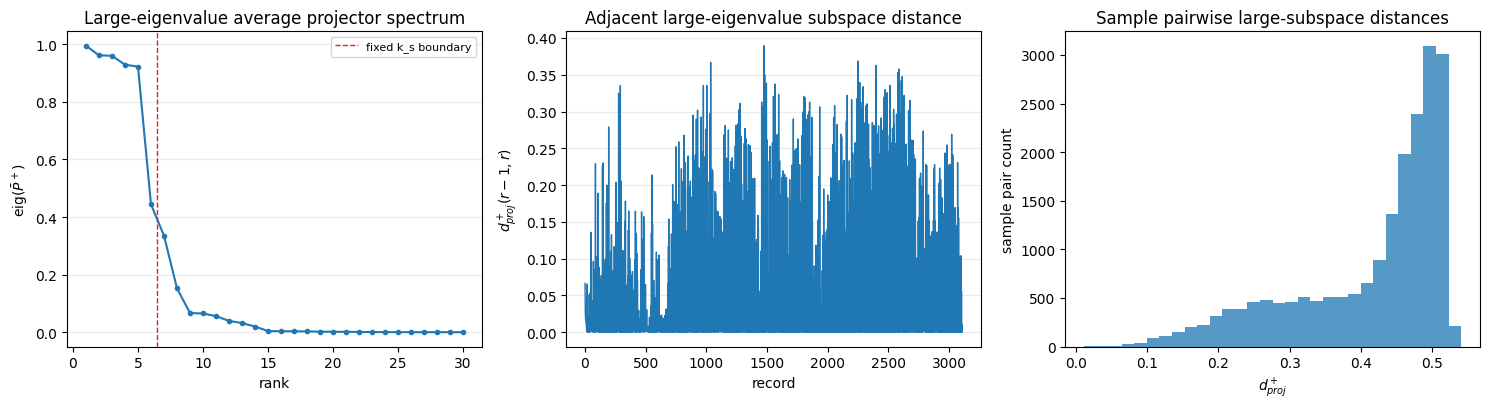

In [57]:
large_fixed_k = max(modal_stiff_count, 1)
large_bases = []
large_projector_sum = np.zeros((nq_a, nq_a), dtype=float)
large_energy_ratio = np.full(num_records, np.nan)

for record_idx in range(num_records):
    basis = fixed_top_eigen_basis(record_idx, large_fixed_k)
    large_bases.append(basis)
    large_projector_sum += basis @ basis.T
    evals = lap_evals_all[record_idx]
    positive_trace = float(np.sum(np.clip(evals, 0.0, None)))
    top_sum = float(np.sum(evals[-large_fixed_k:])) if large_fixed_k else 0.0
    large_energy_ratio[record_idx] = top_sum / positive_trace if positive_trace > 0 else float("nan")

large_projector_avg = large_projector_sum / num_records
large_projector_evals = np.linalg.eigvalsh(large_projector_avg)[::-1]
large_adjacent_distance = np.full(num_records, np.nan)
for record_idx in range(1, num_records):
    large_adjacent_distance[record_idx] = subspace_projection_distance(
        large_bases[record_idx - 1],
        large_bases[record_idx],
    )

pair_sample_size = min(200, num_records)
pair_sample_records = np.unique(np.linspace(0, num_records - 1, pair_sample_size, dtype=int))
large_pairwise_distances = []
for i, record_a in enumerate(pair_sample_records):
    for record_b in pair_sample_records[i + 1:]:
        large_pairwise_distances.append(
            subspace_projection_distance(large_bases[record_a], large_bases[record_b])
        )
large_pairwise_distances = np.asarray(large_pairwise_distances, dtype=float)

show_note("**Large-eigenvalue fixed-k setting**")
large_fixed_k_rows = [
    {"metric": "fixed_k_s", "value": large_fixed_k},
]
show_df(pd.DataFrame(large_fixed_k_rows))

show_note("**Large-eigenvalue subspace stability**")
large_subspace_stability_rows = [
    {"metric": "avg_projector_eig_1", "value": float(large_projector_evals[0])},
    {"metric": f"avg_projector_eig_{large_fixed_k}", "value": float(large_projector_evals[large_fixed_k - 1])},
    {"metric": "adjacent_d_proj_p50", "value": float(np.nanpercentile(large_adjacent_distance, 50))},
    {"metric": "adjacent_d_proj_p95", "value": float(np.nanpercentile(large_adjacent_distance, 95))},
    {"metric": "pairwise_d_proj_p50", "value": float(np.nanpercentile(large_pairwise_distances, 50))},
    {"metric": "pairwise_d_proj_p95", "value": float(np.nanpercentile(large_pairwise_distances, 95))},
]
show_df(pd.DataFrame(large_subspace_stability_rows))

show_note("**Large-eigenvalue curvature energy concentration**")
large_energy_rows = [
    {"metric": "stiff_energy_ratio_p50", "value": float(np.nanpercentile(large_energy_ratio, 50))},
    {"metric": "stiff_energy_ratio_p95", "value": float(np.nanpercentile(large_energy_ratio, 95))},
]
show_df(pd.DataFrame(large_energy_rows))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
rank_axis = np.arange(1, len(large_projector_evals) + 1)
ax.plot(rank_axis, large_projector_evals, marker="o", markersize=3, linewidth=1.5)
ax.axvline(large_fixed_k + 0.5, color="tab:red", linestyle="--", linewidth=1, label="fixed k_s boundary")
ax.set_title("Large-eigenvalue average projector spectrum")
ax.set_xlabel("rank")
ax.set_ylabel(r"eig$(\bar P^+)$")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.25)

ax = axes[1]
ax.plot(np.arange(num_records), large_adjacent_distance, linewidth=1.0)
ax.set_title("Adjacent large-eigenvalue subspace distance")
ax.set_xlabel("record")
ax.set_ylabel(r"$d_{proj}^+(r-1,r)$")
ax.grid(True, axis="y", alpha=0.25)

ax = axes[2]
ax.hist(large_pairwise_distances[np.isfinite(large_pairwise_distances)], bins=30, color="tab:blue", alpha=0.75)
ax.set_title("Sample pairwise large-subspace distances")
ax.set_xlabel(r"$d_{proj}^+$")
ax.set_ylabel("sample pair count")

plt.tight_layout()
plt.show()



## 5 Large-Eigenvalue Attribution Across Records

对每条 record $r$，设 active configuration 维度为 $n_q$，Laplacian residual 行数为 $m_r$。本节使用以下矩阵：

- $J_{\mathrm{lap},r}\in\mathbb{R}^{m_r\times n_q}$：saved Laplacian residual Jacobian。
- $w_r\in\mathbb{R}_+^{m_r}$：saved row weights，$W_r=\operatorname{diag}(w_r)$。
- $A_r=W_r^{1/2}J_{\mathrm{lap},r}=\operatorname{diag}(\sqrt{w_r})J_{\mathrm{lap},r}$，因此 $H_{\mathrm{lap},r}=2A_r^TA_r$。
- $S_r^+\in\mathbb{R}^{n_q\times k_s}$：$H_{\mathrm{lap},r}$ 的前 $k_s$ 个最大特征值对应的正交归一特征向量。
- $P_B\in\mathbb{R}^{n_q\times n_q}$：变量 block $B$ 的 diagonal coordinate selector。若第 $i$ 个 active $q$ 坐标属于 block $B$，则 $(P_B)_{ii}=1$，否则为 $0$。
- $P_i=e_ie_i^T$：单个 active $q$ 坐标 $i$ 的 coordinate selector。浮基细分分析使用 $i\in\{0,\ldots,6\}$，对应 `base_x`、`base_y`、`base_z`、`base_qw`、`base_qx`、`base_qy`、`base_qz`。
- $R_G\in\mathbb{R}^{|G|\times m_r}$：residual row group $G$ 的 row selector。$R_GA_r$ 只保留属于 group $G$ 的 residual rows。

large-eigenvalue weighted residual response 定义为：

$$
Y_r^+=A_rS_r^+.
$$

$Y_r^+\in\mathbb{R}^{m_r\times k_s}$ 表示 large-eigenvalue directions 在加权 residual 空间中的响应。

变量 block $B$ 的 block-only response fraction 定义为：

$$
b_B^{+(r)}
=
\frac{\|A_rP_BS_r^+\|_F^2}{\|A_rS_r^+\|_F^2}.
$$

$b_B^{+(r)}$ 衡量 large-eigenvalue response 中由 block $B$ 坐标单独产生的比例。
单个坐标 $i$ 的 block-only response 是同一公式的特例：

$$
b_i^{+(r)}
=
\frac{\|A_rP_iS_r^+\|_F^2}{\|A_rS_r^+\|_F^2}.
$$

浮基细分分析逐个统计 $i=0,\ldots,6$ 的 $b_i^{+(r)}$。

block cross term 定义为：

$$
c_{BC}^{+(r)}
=
\frac{2\langle A_rP_BS_r^+,A_rP_CS_r^+\rangle_F}
{\|A_rS_r^+\|_F^2}.
$$

$\langle U,V\rangle_F=\operatorname{tr}(U^TV)$。$c_{BC}^{+(r)}$ 衡量 block $B$ 和 block $C$ 的 residual response 是否同向或抵消。若 variable blocks 构成一个坐标划分，则 total response energy 可分解为 block-only quadratic terms 和 cross terms。单个浮基坐标之间的 cross-response 使用同一公式，把 $P_B,P_C$ 换成 $P_i,P_j$。

residual row group $G$ 的 response fraction 定义为：

$$
\rho_G^{+(r)}
=
\frac{\|R_GA_rS_r^+\|_F^2}{\|A_rS_r^+\|_F^2}.
$$

$\rho_G^{+(r)}$ 衡量 large-eigenvalue response 落在 residual row group $G$ 上的比例。若 row groups 构成 residual rows 的划分，则 $\sum_G\rho_G^{+(r)}=1$，只差数值误差。


**Large-eigenvalue variable-block block-only response percentiles**

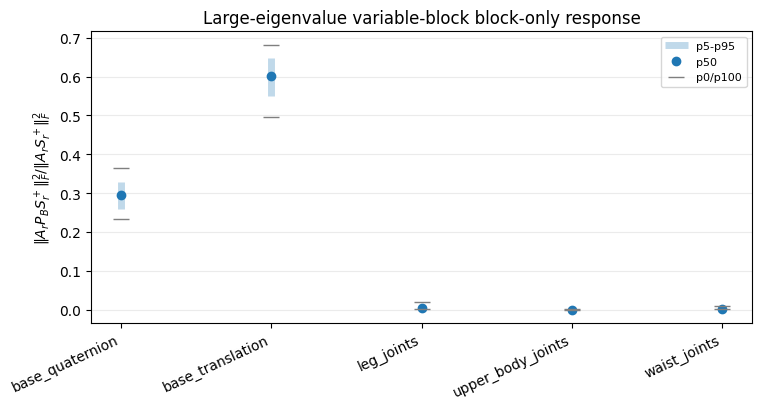

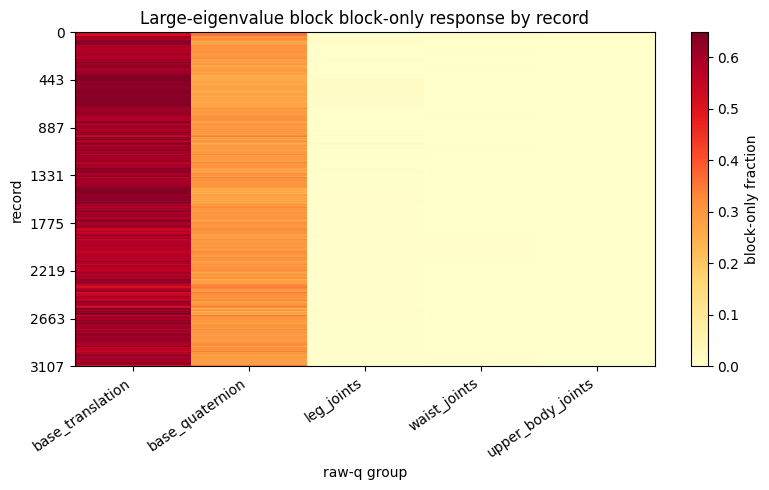

**Floating-base coordinate block-only response by record**

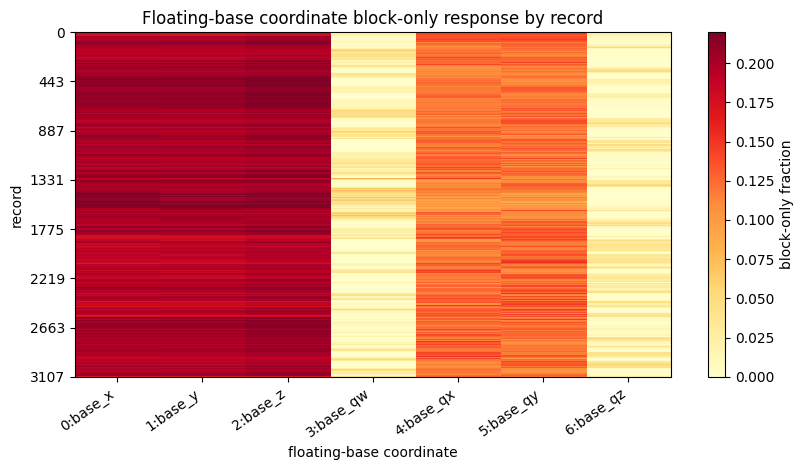

**Floating-base coordinate cross-response percentiles**

metric,p0,p5,p50,p95,p100,abs_p95
3:base_qw x 6:base_qz,-0.000147,0.000240,0.009242,0.025573,0.041496,0.025573
3:base_qw x 5:base_qy,-0.001954,-0.000424,0.002661,0.009173,0.017595,0.009173
4:base_qx x 6:base_qz,-0.001639,-0.000173,0.002769,0.009008,0.015383,0.009008
1:base_y x 3:base_qw,-0.000280,-0.000022,0.000213,0.005006,0.016096,0.005006
1:base_y x 6:base_qz,-0.000527,-0.000020,0.000228,0.004361,0.010731,0.004361
0:base_x x 6:base_qz,-0.001025,-0.000002,0.000549,0.003180,0.007386,0.003180
0:base_x x 3:base_qw,-0.000729,0.000002,0.000537,0.003088,0.009074,0.003088
5:base_qy x 6:base_qz,-0.001878,-0.000894,0.000003,0.002226,0.008032,0.002226
3:base_qw x 4:base_qx,-0.002255,-0.000866,0.000035,0.002014,0.007165,0.002053
1:base_y x 4:base_qx,-0.004825,-0.001361,0.000132,0.000755,0.001579,0.001386


**Large-eigenvalue block cross-response percentiles**

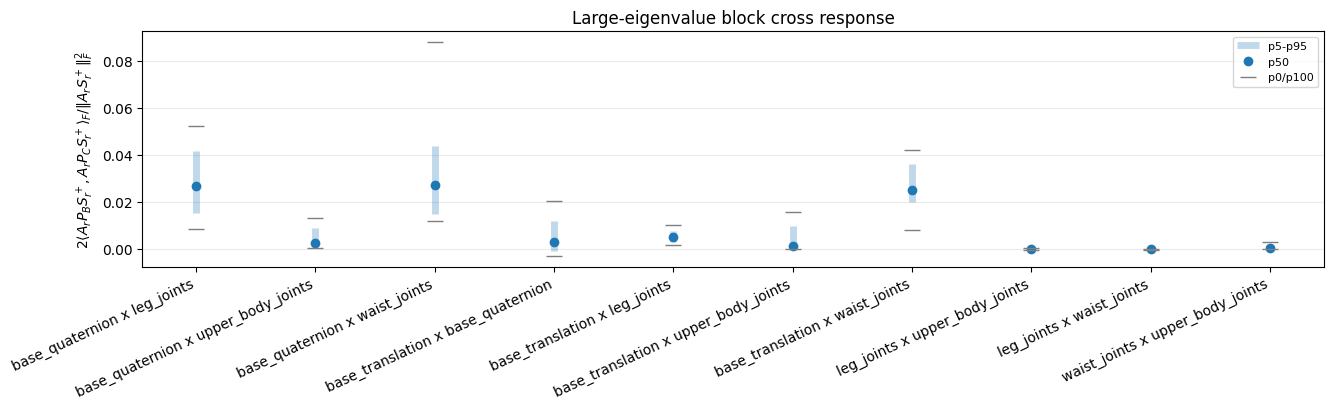

**Large-eigenvalue residual-row response percentiles**

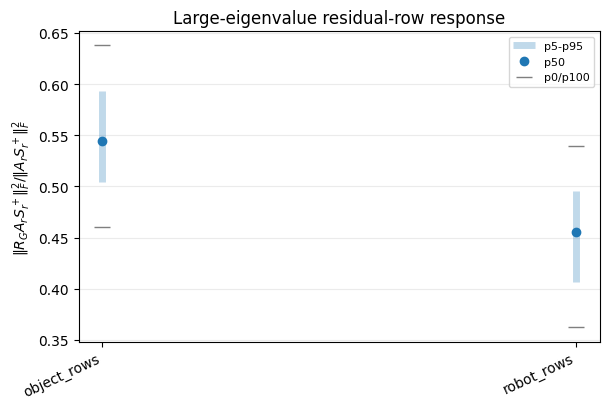

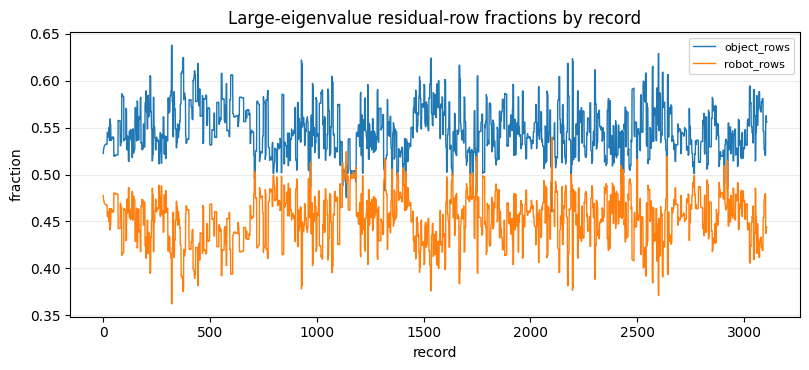

In [58]:
large_block_rows = []
large_cross_rows = []
large_row_rows = []
large_coord_rows = []
large_base_coord_cross_rows = []

group_names = list(RAW_Q_GROUPS)
base_coord_count = min(7, nq_a)
base_coord_indices = list(range(base_coord_count))
for record_idx in range(num_records):
    A_lap = weighted_lap_A_raw_q(record_idx)
    S = large_bases[record_idx]
    response = A_lap @ S
    denom = float(np.sum(response**2))
    if denom <= 0:
        continue

    block_responses = {}
    for group_name, sl in RAW_Q_GROUPS.items():
        masked = np.zeros_like(S)
        if sl.start < sl.stop:
            masked[sl, :] = S[sl, :]
        block_response = A_lap @ masked
        block_responses[group_name] = block_response
        large_block_rows.append(
            {
                "record": int(record_idx),
                "frame": int(hessian_frame[record_idx]),
                "inner_iter": int(hessian_inner_iter[record_idx]),
                "group": group_name,
                "block_only_norm_sq": float(np.sum(block_response**2)),
                "block_only_fraction": float(np.sum(block_response**2) / denom),
            }
        )

    base_coord_responses = {}
    for raw_q_index, coord_name in enumerate(raw_q_names):
        masked = np.zeros_like(S)
        masked[raw_q_index, :] = S[raw_q_index, :]
        coord_response = A_lap @ masked
        coord_value = float(np.sum(coord_response**2))
        if raw_q_index in base_coord_indices:
            base_coord_responses[raw_q_index] = coord_response
        large_coord_rows.append(
            {
                "record": int(record_idx),
                "frame": int(hessian_frame[record_idx]),
                "inner_iter": int(hessian_inner_iter[record_idx]),
                "raw_q_index": int(raw_q_index),
                "coord": coord_name,
                "coord_label": f"{raw_q_index}:{coord_name}",
                "block_only_norm_sq": coord_value,
                "block_only_fraction": coord_value / denom,
            }
        )

    for i, coord_a in enumerate(base_coord_indices):
        for coord_b in base_coord_indices[i + 1:]:
            cross_value = float(2.0 * np.sum(base_coord_responses[coord_a] * base_coord_responses[coord_b]))
            large_base_coord_cross_rows.append(
                {
                    "record": int(record_idx),
                    "frame": int(hessian_frame[record_idx]),
                    "inner_iter": int(hessian_inner_iter[record_idx]),
                    "coord_pair": f"{coord_a}:{raw_q_names[coord_a]} x {coord_b}:{raw_q_names[coord_b]}",
                    "cross_term": cross_value,
                    "cross_fraction": cross_value / denom,
                    "abs_cross_fraction": abs(cross_value / denom),
                }
            )

    for i, group_a in enumerate(group_names):
        for group_b in group_names[i + 1:]:
            cross_value = float(2.0 * np.sum(block_responses[group_a] * block_responses[group_b]))
            large_cross_rows.append(
                {
                    "record": int(record_idx),
                    "frame": int(hessian_frame[record_idx]),
                    "group_pair": f"{group_a} x {group_b}",
                    "cross_term": cross_value,
                    "cross_fraction": cross_value / denom,
                    "abs_cross_fraction": abs(cross_value / denom),
                }
            )

    for row_group, sl in lap_residual_row_groups(record_idx).items():
        group_value = float(np.sum(response[sl, :] ** 2)) if sl.start < sl.stop else 0.0
        large_row_rows.append(
            {
                "record": int(record_idx),
                "frame": int(hessian_frame[record_idx]),
                "row_group": row_group,
                "row_count": int(sl.stop - sl.start),
                "response_norm_sq": group_value,
                "fraction": group_value / denom,
            }
        )

large_block_df = pd.DataFrame(large_block_rows)
large_coord_df = pd.DataFrame(large_coord_rows)
large_cross_df = pd.DataFrame(large_cross_rows)
large_base_coord_cross_df = pd.DataFrame(large_base_coord_cross_rows)
large_row_df = pd.DataFrame(large_row_rows)

show_note("**Large-eigenvalue variable-block block-only response percentiles**")
block_percentile_rows = []
for group_name, group in large_block_df.groupby("group"):
    row = percentile_row(group_name, group["block_only_fraction"])
    block_percentile_rows.append(row)
large_block_percentile_df = plot_percentile_rows(
    block_percentile_rows,
    "Large-eigenvalue variable-block block-only response",
    r"$\|A_rP_BS_r^+\|_F^2 / \|A_rS_r^+\|_F^2$",
)

large_block_matrix = (
    large_block_df
    .pivot_table(index="record", columns="group", values="block_only_fraction", aggfunc="first")
    .reindex(columns=group_names)
    .sort_index()
)
fig, ax = plt.subplots(figsize=(8.2, 5.0))
im = ax.imshow(
    large_block_matrix.to_numpy(),
    aspect="auto",
    interpolation="nearest",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=float(np.nanpercentile(large_block_matrix.to_numpy(), 99)),
)
ax.set_title("Large-eigenvalue block block-only response by record")
ax.set_xlabel("raw-q group")
ax.set_ylabel("record")
ax.set_xticks(np.arange(len(large_block_matrix.columns)))
ax.set_xticklabels(large_block_matrix.columns, rotation=35, ha="right")
if len(large_block_matrix.index):
    ytick_positions = np.linspace(0, len(large_block_matrix.index) - 1, min(8, len(large_block_matrix.index)), dtype=int)
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(large_block_matrix.index.to_numpy()[ytick_positions])
fig.colorbar(im, ax=ax, label="block-only fraction")
plt.tight_layout()
plt.show()

large_base_coord_df = large_coord_df[large_coord_df["raw_q_index"].isin(base_coord_indices)].copy()

show_note("**Floating-base coordinate block-only response by record**")
large_base_coord_matrix = (
    large_base_coord_df
    .pivot_table(index="record", columns="raw_q_index", values="block_only_fraction", aggfunc="first")
    .reindex(columns=base_coord_indices)
    .sort_index()
)
large_base_coord_values = large_base_coord_matrix.to_numpy(dtype=float)
large_base_coord_vmax = float(np.nanpercentile(large_base_coord_values, 99)) if np.isfinite(large_base_coord_values).any() else 1.0
large_base_coord_vmax = max(large_base_coord_vmax, 1e-12)
large_base_coord_tick_labels = (
    raw_q_index_map_df
    .set_index("raw_q_index")
    .reindex(base_coord_indices)["coord_label"]
    .tolist()
)
fig, ax = plt.subplots(figsize=(8.4, 4.8))
im = ax.imshow(
    large_base_coord_values,
    aspect="auto",
    interpolation="nearest",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=large_base_coord_vmax,
)
ax.set_title("Floating-base coordinate block-only response by record")
ax.set_xlabel("floating-base coordinate")
ax.set_ylabel("record")
ax.set_xticks(np.arange(len(large_base_coord_matrix.columns)))
ax.set_xticklabels(large_base_coord_tick_labels, rotation=35, ha="right")
if len(large_base_coord_matrix.index):
    ytick_positions = np.linspace(0, len(large_base_coord_matrix.index) - 1, min(8, len(large_base_coord_matrix.index)), dtype=int)
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(large_base_coord_matrix.index.to_numpy()[ytick_positions])
fig.colorbar(im, ax=ax, label="block-only fraction")
plt.tight_layout()
plt.show()

show_note("**Floating-base coordinate cross-response percentiles**")
base_coord_cross_percentile_rows = []
for coord_pair, group in large_base_coord_cross_df.groupby("coord_pair"):
    row = percentile_row(coord_pair, group["cross_fraction"])
    row["abs_p95"] = float(np.nanpercentile(group["abs_cross_fraction"], 95))
    base_coord_cross_percentile_rows.append(row)
large_base_coord_cross_percentile_df = (
    pd.DataFrame(base_coord_cross_percentile_rows)
    .sort_values("abs_p95", ascending=False)
    .reset_index(drop=True)
)
show_df(large_base_coord_cross_percentile_df.head(12))

show_note("**Large-eigenvalue block cross-response percentiles**")
cross_percentile_rows = []
for group_pair, group in large_cross_df.groupby("group_pair"):
    cross_percentile_rows.append(percentile_row(group_pair, group["cross_fraction"]))
large_cross_percentile_df = plot_percentile_rows(
    cross_percentile_rows,
    "Large-eigenvalue block cross response",
    r"$2\langle A_rP_BS_r^+,A_rP_CS_r^+\rangle_F / \|A_rS_r^+\|_F^2$",
)

show_note("**Large-eigenvalue residual-row response percentiles**")
row_percentile_rows = []
for row_group, group in large_row_df.groupby("row_group"):
    row_percentile_rows.append(percentile_row(row_group, group["fraction"]))
large_row_percentile_df = plot_percentile_rows(
    row_percentile_rows,
    "Large-eigenvalue residual-row response",
    r"$\|R_GA_rS_r^+\|_F^2 / \|A_rS_r^+\|_F^2$",
)

large_row_matrix = (
    large_row_df
    .pivot_table(index="record", columns="row_group", values="fraction", aggfunc="first")
    .sort_index()
)
fig, ax = plt.subplots(figsize=(8.2, 3.8))
for column in large_row_matrix.columns:
    ax.plot(large_row_matrix.index, large_row_matrix[column], linewidth=1.0, label=column)
ax.set_title("Large-eigenvalue residual-row fractions by record")
ax.set_xlabel("record")
ax.set_ylabel("fraction")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 6 Near-Null Subspace Stability

本节使用 fixed $k_0$ near-null basis：

$$
N_r=[u_n^{(r)},u_{n-1}^{(r)},\ldots,u_{n-k_0+1}^{(r)}],
\qquad
k_0=\operatorname{mode}(k_0^{(r)}).
$$

Projector stability 与 large-eigenvalue 侧一致：

$$
P_r^0=N_rN_r^T,\qquad
\bar P^0=\frac{1}{R}\sum_rP_r^0.
$$

相邻 records 的 near-null distance 使用同一 normalized projection distance：

$$
d_{\mathrm{proj}}^0(r-1,r)
=\sqrt{1-\frac{1}{k_0}\|N_{r-1}^\top N_r\|_F^2}.
$$

令 $\phi_i$ 表示 $N_{r-1}$ 与 $N_r$ 的 near-null principal angles，且 $\sigma_i(N_{r-1}^\top N_r)=\cos\phi_i$，则

$$
d_{\mathrm{proj}}^0
=\sqrt{1-\frac{1}{k_0}\sum_{i=1}^{k_0}\cos^2\phi_i}.
$$


**Near-null fixed-k setting**

metric,value
fixed_k_0,1


**Near-null subspace stability**

metric,value
avg_projector_eig_1,0.576166
avg_projector_eig_1,0.576166
adjacent_d_proj_p50,0.003729
adjacent_d_proj_p95,0.197809
pairwise_d_proj_p50,0.693992
pairwise_d_proj_p95,0.997266


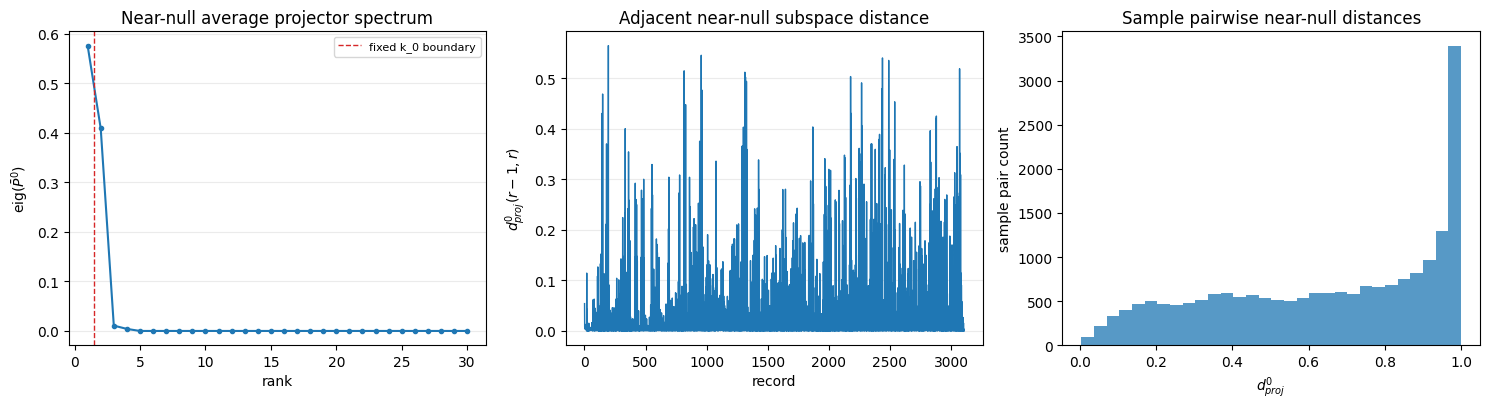

In [59]:
near_fixed_k = max(modal_near_zero_count, 1)
near_bases = []
near_projector_sum = np.zeros((nq_a, nq_a), dtype=float)

for record_idx in range(num_records):
    basis = fixed_bottom_eigen_basis(record_idx, near_fixed_k)
    near_bases.append(basis)
    near_projector_sum += basis @ basis.T

near_projector_avg = near_projector_sum / num_records
near_projector_evals = np.linalg.eigvalsh(near_projector_avg)[::-1]
near_adjacent_distance = np.full(num_records, np.nan)
for record_idx in range(1, num_records):
    near_adjacent_distance[record_idx] = subspace_projection_distance(
        near_bases[record_idx - 1],
        near_bases[record_idx],
    )

near_pairwise_distances = []
for i, record_a in enumerate(pair_sample_records):
    for record_b in pair_sample_records[i + 1:]:
        near_pairwise_distances.append(
            subspace_projection_distance(near_bases[record_a], near_bases[record_b])
        )
near_pairwise_distances = np.asarray(near_pairwise_distances, dtype=float)

show_note("**Near-null fixed-k setting**")
near_fixed_k_rows = [
    {"metric": "fixed_k_0", "value": near_fixed_k},
]
show_df(pd.DataFrame(near_fixed_k_rows))

show_note("**Near-null subspace stability**")
near_stability_rows = [
    {"metric": "avg_projector_eig_1", "value": float(near_projector_evals[0])},
    {"metric": f"avg_projector_eig_{near_fixed_k}", "value": float(near_projector_evals[near_fixed_k - 1])},
    {"metric": "adjacent_d_proj_p50", "value": float(np.nanpercentile(near_adjacent_distance, 50))},
    {"metric": "adjacent_d_proj_p95", "value": float(np.nanpercentile(near_adjacent_distance, 95))},
    {"metric": "pairwise_d_proj_p50", "value": float(np.nanpercentile(near_pairwise_distances, 50))},
    {"metric": "pairwise_d_proj_p95", "value": float(np.nanpercentile(near_pairwise_distances, 95))},
]
show_df(pd.DataFrame(near_stability_rows))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
rank_axis = np.arange(1, len(near_projector_evals) + 1)
ax.plot(rank_axis, near_projector_evals, marker="o", markersize=3, linewidth=1.5)
ax.axvline(near_fixed_k + 0.5, color="tab:red", linestyle="--", linewidth=1, label="fixed k_0 boundary")
ax.set_title("Near-null average projector spectrum")
ax.set_xlabel("rank")
ax.set_ylabel(r"eig$(\bar P^0)$")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.25)

ax = axes[1]
ax.plot(np.arange(num_records), near_adjacent_distance, linewidth=1.0)
ax.set_title("Adjacent near-null subspace distance")
ax.set_xlabel("record")
ax.set_ylabel(r"$d_{proj}^0(r-1,r)$")
ax.grid(True, axis="y", alpha=0.25)

ax = axes[2]
ax.hist(near_pairwise_distances[np.isfinite(near_pairwise_distances)], bins=30, color="tab:blue", alpha=0.75)
ax.set_title("Sample pairwise near-null distances")
ax.set_xlabel(r"$d_{proj}^0$")
ax.set_ylabel("sample pair count")

plt.tight_layout()
plt.show()


## 7 Near-Null Attribution Across Records

Near-null basis 满足 $A_rN_r\approx0$。归因使用 raw-coordinate participation 和 weak-visibility chain。

raw-coordinate group participation：

$$
g_B^{0(r)}
=
\frac{\|P_BN_r\|_F^2}{\|N_r\|_F^2}.
$$

weak-visibility chain：

$$
R_V^{(r)}=\frac{1}{k_0}\|J_{V,r}N_r\|_F^2,
$$

$$
R_L^{(r)}
=
\frac{\|J_{\mathrm{lap},r}N_r\|_F^2}
{\|J_{V,r}N_r\|_F^2+\epsilon},
\qquad
R_W^{(r)}
=
\frac{\|A_rN_r\|_F^2}
{\|J_{\mathrm{lap},r}N_r\|_F^2+\epsilon}.
$$


**Near-null weak-visibility chain percentiles**

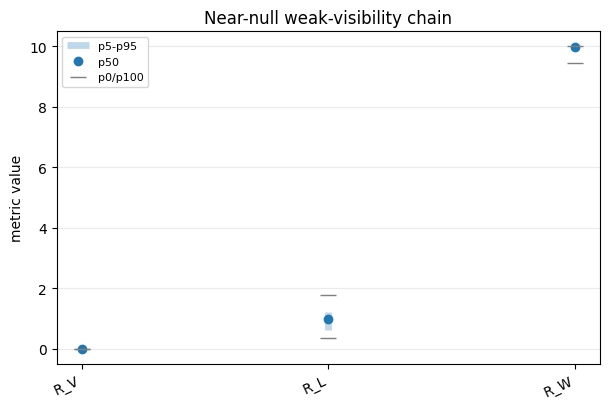

**Near-null group participation percentiles**

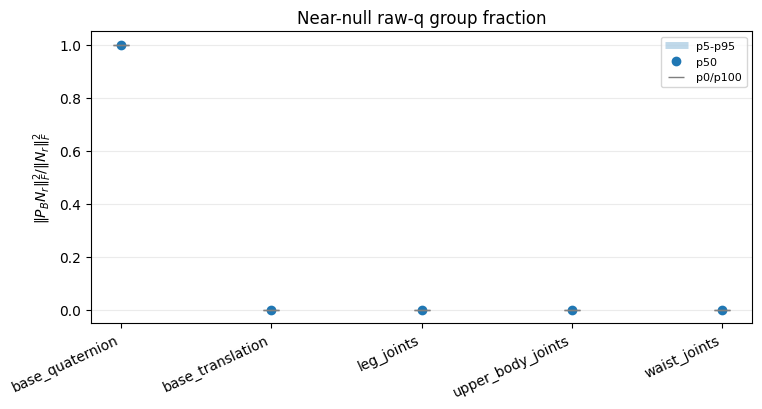

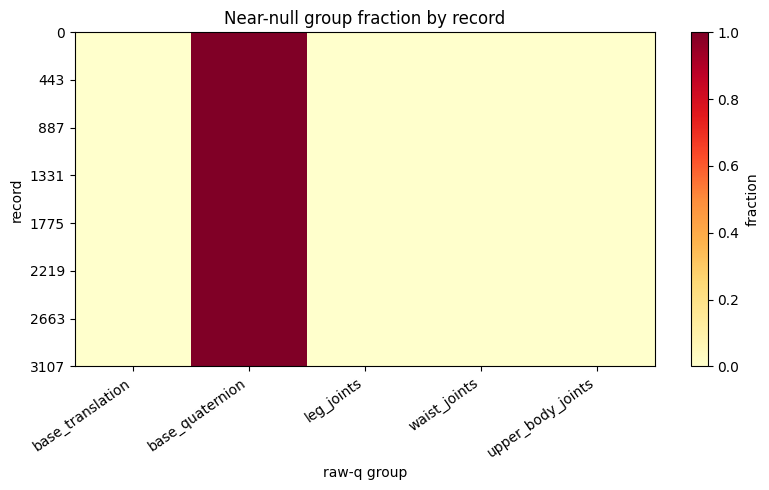

**Near-null single-coordinate fraction heatmap**

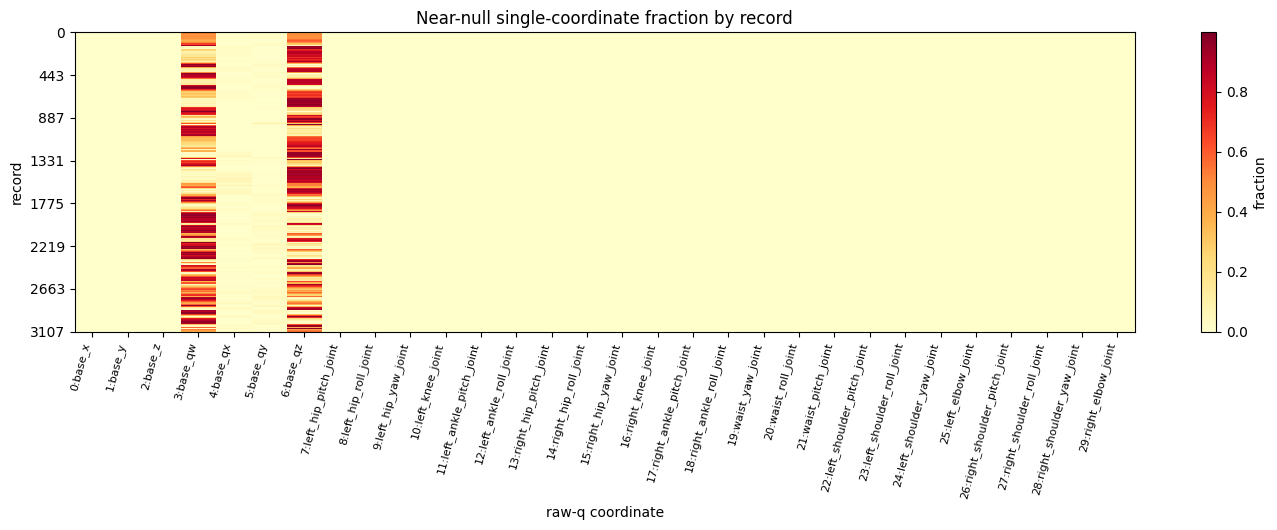

In [60]:
def subspace_response_from_arrays(J_V, J_lap, weights, raw_dirs):
    raw_dirs = np.asarray(raw_dirs, dtype=float)
    k = raw_dirs.shape[1]
    if k == 0:
        return {
            "basis_dim": 0,
            "R_V": float("nan"),
            "R_L": float("nan"),
            "R_W": float("nan"),
        }
    weights = np.asarray(weights, dtype=float).reshape(-1)
    J_V_N = J_V @ raw_dirs
    J_lap_N = J_lap @ raw_dirs
    weighted_J_lap_N = np.sqrt(weights)[:, None] * J_lap_N
    JV2 = float(np.sum(J_V_N**2))
    JL2 = float(np.sum(J_lap_N**2))
    JWL2 = float(np.sum(weighted_J_lap_N**2))
    eps = 1e-30
    return {
        "basis_dim": int(k),
        "R_V": JV2 / k,
        "R_L": JL2 / (JV2 + eps),
        "R_W": JWL2 / (JL2 + eps),
    }

near_response_rows = []
near_coord_participation_rows = []
near_group_participation_rows = []

for record_idx in range(num_records):
    N = near_bases[record_idx]
    metrics = subspace_response_from_arrays(
        lap_J_V_all[record_idx],
        lap_J_lap_all[record_idx],
        lap_weights_all[record_idx].reshape(-1),
        N,
    )
    near_response_rows.append(
        {
            "record": int(record_idx),
            "frame": int(hessian_frame[record_idx]),
            "inner_iter": int(hessian_inner_iter[record_idx]),
            "threshold_near0_count": int(lap_metric_series["near_zero_count"][record_idx]),
            "fixed_k": int(N.shape[1]),
            **metrics,
        }
    )

    for item in coordinate_participation_df(N, raw_q_names).itertuples(index=False):
        near_coord_participation_rows.append(
            {
                "record": int(record_idx),
                "frame": int(hessian_frame[record_idx]),
                "raw_q_index": int(item.raw_q_index),
                "coord": item.coord,
                "coord_label": item.coord_label,
                "participation": float(item.participation),
                "fraction": float(item.fraction),
            }
        )
    for item in group_participation_df(N, RAW_Q_GROUPS).itertuples(index=False):
        near_group_participation_rows.append(
            {
                "record": int(record_idx),
                "frame": int(hessian_frame[record_idx]),
                "group": item.group,
                "participation": float(item.participation),
                "fraction": float(item.fraction),
            }
        )

near_response_df = pd.DataFrame(near_response_rows)
near_coord_participation_df = pd.DataFrame(near_coord_participation_rows)
near_group_participation_df = pd.DataFrame(near_group_participation_rows)

show_note("**Near-null weak-visibility chain percentiles**")
source_rows = [
    percentile_row("R_V", near_response_df["R_V"]),
    percentile_row("R_L", near_response_df["R_L"]),
    percentile_row("R_W", near_response_df["R_W"]),
]
near_source_percentile_df = plot_percentile_rows(
    source_rows,
    "Near-null weak-visibility chain",
    "metric value",
)

show_note("**Near-null group participation percentiles**")
near_group_rows = []
for group_name, group in near_group_participation_df.groupby("group"):
    near_group_rows.append(percentile_row(group_name, group["fraction"]))
near_group_percentile_df = plot_percentile_rows(
    near_group_rows,
    "Near-null raw-q group fraction",
    r"$\|P_BN_r\|_F^2 / \|N_r\|_F^2$",
)

near_group_matrix = (
    near_group_participation_df
    .pivot_table(index="record", columns="group", values="fraction", aggfunc="first")
    .reindex(columns=list(RAW_Q_GROUPS))
    .sort_index()
)
fig, ax = plt.subplots(figsize=(8.2, 5.0))
im = ax.imshow(
    near_group_matrix.to_numpy(),
    aspect="auto",
    interpolation="nearest",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=1.0,
)
ax.set_title("Near-null group fraction by record")
ax.set_xlabel("raw-q group")
ax.set_ylabel("record")
ax.set_xticks(np.arange(len(near_group_matrix.columns)))
ax.set_xticklabels(near_group_matrix.columns, rotation=35, ha="right")
if len(near_group_matrix.index):
    ytick_positions = np.linspace(0, len(near_group_matrix.index) - 1, min(8, len(near_group_matrix.index)), dtype=int)
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(near_group_matrix.index.to_numpy()[ytick_positions])
fig.colorbar(im, ax=ax, label="fraction")
plt.tight_layout()
plt.show()

show_note("**Near-null single-coordinate fraction heatmap**")
near_coord_matrix = (
    near_coord_participation_df
    .pivot_table(index="record", columns="raw_q_index", values="fraction", aggfunc="first")
    .sort_index()
)
near_coord_values = near_coord_matrix.to_numpy(dtype=float)
near_coord_vmax = float(np.nanmax(near_coord_values)) if np.isfinite(near_coord_values).any() else 1.0
near_coord_vmax = max(near_coord_vmax, 1e-12)
near_coord_tick_labels = (
    raw_q_index_map_df
    .set_index("raw_q_index")
    .reindex(near_coord_matrix.columns)["coord_label"]
    .tolist()
)
fig, ax = plt.subplots(figsize=(max(12.0, 0.34 * len(near_coord_matrix.columns) + 4.0), 5.4))
im = ax.imshow(
    near_coord_values,
    aspect="auto",
    interpolation="nearest",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=near_coord_vmax,
)
ax.set_title("Near-null single-coordinate fraction by record")
ax.set_xlabel("raw-q coordinate")
ax.set_ylabel("record")
ax.set_xticks(np.arange(len(near_coord_matrix.columns)))
ax.set_xticklabels(near_coord_tick_labels, rotation=75, ha="right", fontsize=8)
if len(near_coord_matrix.index):
    ytick_positions = np.linspace(0, len(near_coord_matrix.index) - 1, min(8, len(near_coord_matrix.index)), dtype=int)
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(near_coord_matrix.index.to_numpy()[ytick_positions])
fig.colorbar(im, ax=ax, label="fraction")
plt.tight_layout()
plt.show()
